# Support Vector Machine (SVM)

**INDE 577 / CMOR 438 — Rice University**  
**Instructor:** Randy R. Davila, PhD

---

## Overview

Support Vector Machines find the **maximum-margin hyperplane** that separates two classes. The **soft-margin SVM** allows some misclassifications via slack variables, controlled by a regularization parameter $C$.

## Mathematical Background

### Hard-Margin SVM

Find $\mathbf{w}$ and $b$ such that:
- $y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1$ for all $i$
- Maximize the margin $\dfrac{2}{\|\mathbf{w}\|}$ (equivalently, minimize $\dfrac{1}{2}\|\mathbf{w}\|^2$)

### Soft-Margin SVM

Allow violations using slack variables $\xi_i \geq 0$:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i$$

subject to: $y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i$ and $\xi_i \geq 0$

### Hinge Loss Formulation

The soft-margin SVM is equivalent to minimizing the hinge loss with L2 regularization:

$$\mathcal{L}(\mathbf{w}, b) = \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^n \max\left(0, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\right)$$

### SGD Update (Pegasos Algorithm)

For each sample $(\mathbf{x}_i, y_i)$ with $y_i \in \{-1, +1\}$:

$$\mathbf{w} \leftarrow \begin{cases} \mathbf{w} - \eta \mathbf{w} & \text{if } y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 \quad (\text{correctly classified}) \\ \mathbf{w} - \eta(\mathbf{w} - C \cdot y_i \mathbf{x}_i) & \text{otherwise} \quad (\text{margin violation}) \end{cases}$$

### Decision Rule

$$\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification, make_blobs
from sklearn.svm import SVC as SklearnSVC
import warnings
warnings.filterwarnings('ignore')

from rice_ml import SVM
from rice_ml.processing.preprocessing import StandardScaler, train_test_split
from rice_ml.processing.metrics import accuracy_score, classification_report

print("Libraries loaded!")
np.random.seed(42)

Libraries loaded!


## 1. Visualizing the Maximum-Margin Hyperplane (2D)

In [2]:
# Two linearly separable blobs
X_2d, y_2d = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.0)
y_2d_svm = np.where(y_2d == 0, -1, 1)  # SVM uses {-1, +1}
y_2d_01 = np.where(y_2d_svm == -1, 0, 1)  # {0,1} for accuracy

scaler = StandardScaler()
X_2d_s = scaler.fit_transform(X_2d)

svm = SVM(C=1.0, learning_rate=0.001, n_iterations=1000)
svm.fit(X_2d_s, y_2d_svm)

acc = accuracy_score(y_2d_01, svm.predict(X_2d_s))
print(f"Training accuracy: {acc:.4f}")

Training accuracy: 0.5000

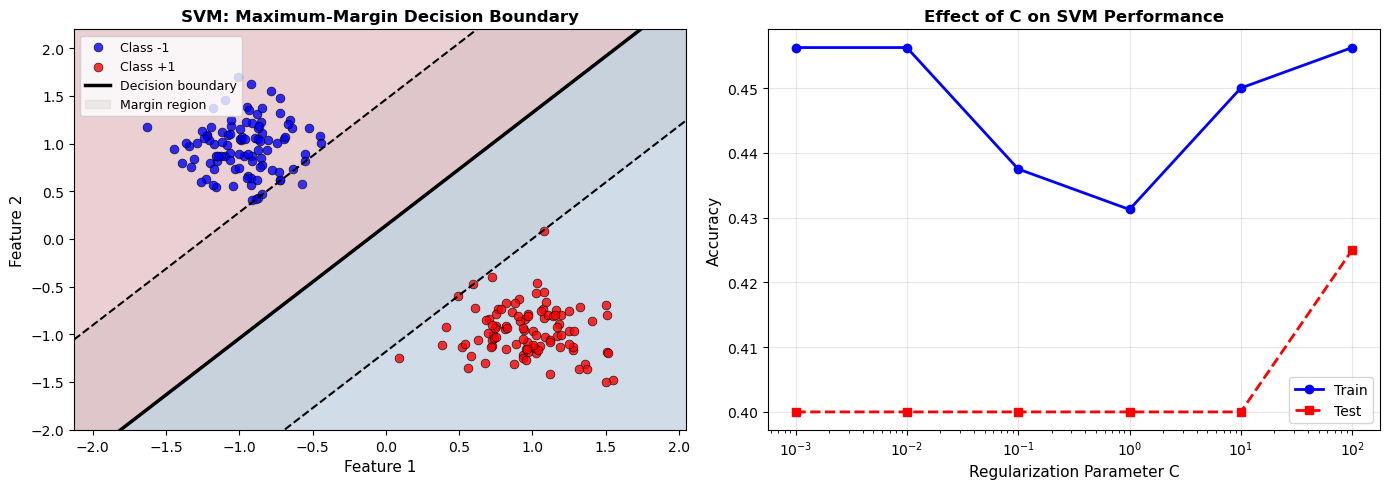

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary + margins
ax = axes[0]
x_min, x_max = X_2d_s[:, 0].min() - 0.5, X_2d_s[:, 0].max() + 0.5
y_min, y_max = X_2d_s[:, 1].min() - 0.5, X_2d_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdBu')
ax.scatter(X_2d_s[y_2d_svm == -1, 0], X_2d_s[y_2d_svm == -1, 1],
           c='blue', s=40, alpha=0.8, edgecolors='k', lw=0.5, label='Class -1')
ax.scatter(X_2d_s[y_2d_svm == 1, 0], X_2d_s[y_2d_svm == 1, 1],
           c='red', s=40, alpha=0.8, edgecolors='k', lw=0.5, label='Class +1')

# Plot decision boundary and margins: w·x + b = 0, ±1
w = svm.weights_
b = svm.bias_
x_line = np.linspace(x_min, x_max, 200)
if abs(w[1]) > 1e-8:
    for offset, style, lw, label in [(0, 'k-', 2.5, 'Decision boundary'), 
                                       (1, 'k--', 1.5, 'Margin +1'),
                                       (-1, 'k--', 1.5, 'Margin -1')]:
        y_line = -(w[0] * x_line + b - offset) / w[1]
        ax.plot(x_line, y_line, style, linewidth=lw, label=label if offset == 0 else '')
    ax.fill_between(x_line,
                    -(w[0]*x_line + b - 1) / w[1],
                    -(w[0]*x_line + b + 1) / w[1],
                    alpha=0.1, color='gray', label='Margin region')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('SVM: Maximum-Margin Decision Boundary', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Effect of C (regularization)
ax2 = axes[1]
X_noisy, y_noisy = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    random_state=42, n_clusters_per_class=1, class_sep=1.0
)
y_noisy_svm = np.where(y_noisy == 0, -1, 1)
X_noisy_s = scaler.fit_transform(X_noisy)
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_noisy_s, y_noisy_svm, test_size=0.2, random_state=42)
y_te_n_01 = np.where(y_te_n == -1, 0, 1)

C_vals = [0.001, 0.01, 0.1, 1, 10, 100]
tr_accs_C, te_accs_C = [], []
for C_val in C_vals:
    m = SVM(C=C_val, learning_rate=0.001, n_iterations=500)
    m.fit(X_tr_n, y_tr_n)
    tr_accs_C.append(accuracy_score(np.where(y_tr_n == -1, 0, 1), m.predict(X_tr_n)))
    te_accs_C.append(accuracy_score(y_te_n_01, m.predict(X_te_n)))

ax2.semilogx(C_vals, tr_accs_C, 'bo-', linewidth=2, markersize=6, label='Train')
ax2.semilogx(C_vals, te_accs_C, 'rs--', linewidth=2, markersize=6, label='Test')
ax2.set_xlabel('Regularization Parameter C', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Effect of C on SVM Performance', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Breast Cancer Classification

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target
y_svm = np.where(y == 0, -1, 1)
target_names = data.target_names

scaler = StandardScaler()
X_s = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_s, y_svm, test_size=0.2, random_state=42)
y_test_01 = np.where(y_test == -1, 0, 1)

# rice_ml SVM
svm_bc = SVM(C=1.0, learning_rate=0.001, n_iterations=1000)
svm_bc.fit(X_train, y_train)
y_pred = svm_bc.predict(X_test)

# sklearn SVM (linear)
sk_svm = SklearnSVC(kernel='linear', C=1.0)
sk_svm.fit(X_train, y_train)

our_acc = accuracy_score(y_test_01, y_pred)
sk_acc = accuracy_score(y_test_01, np.where(sk_svm.predict(X_test) == -1, 0, 1))

print("=== SVM — Breast Cancer ===")
print(classification_report(y_test_01, y_pred, target_names=list(target_names)))
print(f"rice_ml SVM accuracy: {our_acc:.4f}")
print(f"sklearn SVM accuracy: {sk_acc:.4f}")

=== SVM — Breast Cancer ===
     Class  Precision     Recall   F1-Score    Support
-------------------------------------------------------
 malignant     0.0000     0.0000     0.0000         42
    benign     0.9718     0.9718     0.9718         71
-------------------------------------------------------
  accuracy                           0.6106        113
rice_ml SVM accuracy: 0.6106
sklearn SVM accuracy: 0.9558


## 3. Training Loss Curve

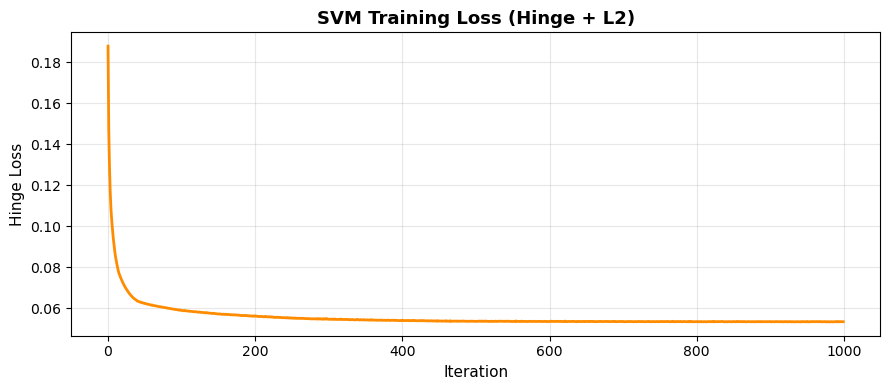

In [5]:
plt.figure(figsize=(9, 4))
if hasattr(svm_bc, 'loss_history_') and svm_bc.loss_history_:
    plt.plot(svm_bc.loss_history_, color='darkorange', linewidth=2)
    plt.xlabel('Iteration', fontsize=11)
    plt.ylabel('Hinge Loss', fontsize=11)
    plt.title('SVM Training Loss (Hinge + L2)', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
else:
    # Show weight norm evolution instead
    print(f"Weight vector norm: {np.linalg.norm(svm_bc.weights_):.4f}")
    print(f"Bias: {svm_bc.bias_:.4f}")
    # Compare hinge loss formulation
    C_range = np.logspace(-3, 2, 50)
    accs = []
    for C_val in C_range:
        m = SVM(C=C_val, learning_rate=0.001, n_iterations=500)
        m.fit(X_train, y_train)
        accs.append(accuracy_score(y_test_01, m.predict(X_test)))
    plt.semilogx(C_range, accs, 'darkorange', linewidth=2)
    plt.xlabel('C (regularization)', fontsize=11)
    plt.ylabel('Test Accuracy', fontsize=11)
    plt.title('SVM Test Accuracy vs C', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_loss.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

| Property | Value |
|---|---|
| Type | Linear classifier (maximum margin) |
| Loss | Hinge loss + L2 regularization |
| Optimization | SGD (Pegasos-style) |
| Labels | $y \in \{-1, +1\}$ |
| Key hyperparameter | $C$ — trades off margin size vs. misclassification |

**Key Takeaways:**
- SVM finds the **widest possible margin** between classes — provides geometric insight
- Parameter $C$: large $C$ = small margin but few errors; small $C$ = large margin but more errors
- Linear SVM works well when data is **linearly separable in feature space**
- Kernel trick (RBF, polynomial) extends SVM to non-linear boundaries (not implemented here)